<h1> The goal of this project: </h1>
1: Import a "dummy dataset" or a simulation data to procces <br>
2: We use a learning model to decide if the cell is mutated or not <br>
3: Write a script that procceses the dataset to find: <br>
    a. Non mutate cells <br>
    b. mutated cells <br>
4: To create a txt file to store the mutated cells data <br>
5: Test it <br>
6: Demonstrate how it works and able to explain the code

The goal of this project is to create a computer program that can look at pictures of cells and decide if they are normal or mutated.
This project aims to help demonstrate how machines can learn from examples, just like humans learn by practice and observation.
The program will be trained using many images so that it can recognize patterns and differences between healthy cells and mutated cells.
Another objective is to understand how image data can be processed and used in machine learning models.
This attempts to explore how artificial intelligence can be utilized in science and medicine to help people.
Ultimately, the goal is to build a working model that can make predictions and show results clearly, so others can grasp how it works.

In [1]:
# !pip install tensorflow

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Import Tensorflow and Keras components for building the CNN.
import tensorflow as tf

# ImageDataGenerator helps you load and prepare images.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# layers and models are used to build the CNN (convolutional neural network).
from tensorflow.keras import layers, models

from tensorflow.keras.models import load_model

# For image prediction.
from tensorflow.keras.preprocessing import image

I0000 00:00:1777164332.654179   35887 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777164332.728807   35887 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777164334.484394   35887 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


<h3>Define Dataset Paths</h3>

In [3]:
# Directories

# ./ means from the current directory.
train_dir = './data/train'

validation_dir = './data/validation'

<h3>Image Preprocessing</h3>

In [4]:
# Create an ImageDataGenerator for training data.
train_datagen = ImageDataGenerator(
    # Normalise the pixel values (0-255 -> 0-1)
    # The closer the pixel value is to 255, the closer it will be
    # to 1.

    # The closer the pixel value is to 0, the closer it will be to
    # to 0.
    rescale=1./225,

    # Random rotation
    rotation_range=20,

    # Horizontal shift
    width_shift_range=0.2,

    # Vertical shift
    height_shift_range=0.2,

    # Applies a shearing transformation which slants the image.
    shear_range=0.2,

    # This randomly zooms in or out of the image by up to 20%.
    zoom_range=0.2,

    # This randomly flips half of the images horizontally.
    horizontal_flip=True
)

# Validation data should not be augmented.
validation_datagen = ImageDataGenerator(rescale=1./255)

<h3>Load the Images</h3>

In [5]:
# Load the training images from directory specified earlier.
train_generator = train_datagen.flow_from_directory(
    train_dir,

    # Resizing all images.
    target_size=(150, 150),
    batch_size=32,

    # Since there are three folders (benign, malignant and normal)
    # you are performing multi-class classification.
    class_mode='binary'
)

# Load the validation images.
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 1998 images belonging to 2 classes.
Found 501 images belonging to 2 classes.


<h3>Build the CNN (Convolutional Neural Network) Model</h3>

In [10]:
# Create a sequential CNN model.

# In this context, sequential means that the data that is inputted
# into this neural network, must go through a sequence of stages
# before it reaches the output.
model = models.Sequential()

# The first convolutional block.

# Conv2D(32, ...) creates 32 different filters (or kernels).
# Think of these as 32 unique maignifying glasses, each looking for
# a different pattern, like a shark edge, a curve or a specific
# texture in your medical scans.

# (3, 3) is the size of the filter. It's a tiny 3x3 pixel square that
# slides across the image to scan it.

# activation='relu' is a mathematical filter that says "If the pattern
# you're looking for isn't there, then ignore it (make it 0). Otherwise,
# keep the vale if it is there.

# relu stands for "Rectified Linear Unit".
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D(2, 2))

# Second convolution block.
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

# Third convolutional block.
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

# Flatten the output because the earlier layers (Convolutional and
# Pooling) work in 3D, but the final decision-making layers (Dense)
# only understand 1D.
model.add(layers.Flatten())

# Dense means that every single one of the neurons in this layer is
# connected to every single number that came out of the Flatten()
# layer.

# 512 is the number of neurons (units). A high number was chosen because
# it gives the model a lot of "memory" to learn complex relationships
# between patterns. It can capture the subtle/hard-to-notice differences
# between benign and malignant tissues.
model.add(layers.Dense(512, activation='relu'))

# Output layer.

# sigmoid takes a single number (logit), and outputs a value between
# 0 and 1. This is simply one probability.

# This is interpreted as:
# P(class = 1)

# class = 1-> malignant (cancerous)
# class = 0 -> benign (non-cancerous)

# This is the model's estimated probability that the input belongs to
# the positive class.

# 1 is the first argument being passed to Dense because for binary
# classification, one neuron should be used.
model.add(layers.Dense(1, activation='sigmoid'))

<h3>Compile the Model</h3>

In [11]:

# Compile the model with optimizer, loss and metrics.
model.compile(
    # adam is an optimizer that automatically adjusts the learning
    # rate as the model trains which is essential for complex medical
    # images.
    optimizer='adam',

    # binary_crossentropy is how your model measures how wrong it is
    # yes/no decisions.

    # We're telling the model how confident it should have been and how
    # greatly it was inaccurate.

    # binary_crossentropy computes a number that measures the error.
    # That number tells the optimiser how to adjust weights.

    # The optimiser uses the error to update the weights.
    loss='binary_crossentropy',

    # Compute the percentage of images that the model guessed correctly.
    # If your model looks at 100 images and correctly identifies 85 of
    # them as either benign, malignant or normal, your accuracy is 0.85
    # or 85%.
    metrics=['accuracy']
)

<h3>Train the Model</h3>

In [13]:
# By saving the output to this variable, you can later plot a graph
# to see if your training accuracy and validation accuracy are moving
# together.
history = model.fit(
    # The engine that feeds your images into the CNN (Convolutional Neural
    # Network).
    train_generator,

    # Specifying the number of batches per epoch.
    steps_per_epoch=100,

    # The number of passes through the dataset.
    epochs=10,

    # Checks the performance during training.
    validation_data=validation_generator,

    # Tells the model exactly how many batches of images to pull
    # from your validation directory to test itself at the end
    # of each epoch.
    validation_steps=50
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 531ms/step - accuracy: 0.7087 - loss: 0.5431 - val_accuracy: 0.7086 - val_loss: 0.6309
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 574ms/step - accuracy: 0.7818 - loss: 0.5146 - val_accuracy: 0.6906 - val_loss: 0.6386
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 613ms/step - accuracy: 0.7878 - loss: 0.4905 - val_accuracy: 0.6727 - val_loss: 0.7158
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 591ms/step - accuracy: 0.8028 - loss: 0.4812 - val_accuracy: 0.6986 - val_loss: 0.6624
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 581ms/step - accuracy: 0.8128 - loss: 0.4747 - val_accuracy: 0.6228 - val_loss: 0.7328
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 62s 616ms/step - accuracy: 0.7052 - loss: 0.6076 - val_accuracy: 0.6866 - val_loss: 0.6138
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 594ms/step - accuracy: 0.7042 - loss: 0.5485 - val_accuracy: 0.6906 - val_loss: 0.6346
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 603ms/step - accuracy: 0.7382 - loss: 0

<h3>Save the Trained Model</h3>

In [14]:
# Save the model so you don't retrain every time.

# The file extension .h5 is a specific file format used to
# save entire Keras/TensorFlow models in a single file.
model.save('./outputs/cancer_model.keras')

<h3>Plot the Training Results</h3>

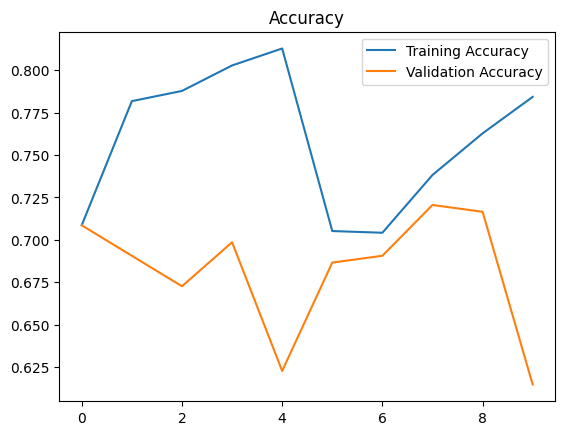

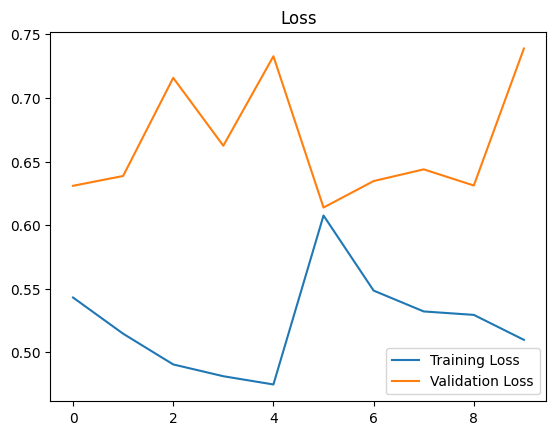

In [15]:
# Extract the accuracy and the loss.
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the accuracy.
plt.plot(accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

# Useful if you have to display multiple plots.
plt.show()

# Plot the loss.
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

<h3>Load and Predict on a New Image</h3>

In [16]:
# Import the image preprocessing utilities from Keras.
# This module provides functions to load images from disk and
# convert them into numerical arrays that a neural network can use.
from tensorflow.keras.preprocessing import image

# Define the file path to the test image that we want the model to classify.
# This should point to an image that was NOT used during training.
img_path = './test_images/test_image.jpg'

# Load the image from disk and resize it to match the input size
# expected by the model (150x150 pixels). The model cannot accept
# arbitrary image sizes, so this step ensures consistency.
img = image.load_img(img_path, target_size=(150,150))

# Convert the loaded PIL image into a NumPy array.
# The resulting shape will be (150, 150, 3), where:
# 150x150 is the image size and 3 represents RGB color channels.
img_array = image.img_to_array(img)

# Normalize pixel values from the range [0, 255] to [0, 1].
# This matches the preprocessing used during training and helps
# the model make stable and accurate predictions.
img_array = img_array / 255.0

# Add an extra dimension to represent the batch size.
# The model expects input of shape (batch_size, height, width, channels),
# so this converts the array from (150,150,3) -> (1,150,150,3).
img_array = np.expand_dims(img_array, axis=0)

# Pass the processed image into the trained model to get a prediction.
# The output will be a probability score between 0 and 1.
prediction = model.predict(img_array)

# Interpret the prediction result:
# - A value close to 1 indicates malignant (cancerous).
# - A value close to 0 indicates benign (non-cancerous).
# The threshold of 0.5 is used to decide between the two classes.
if prediction[0][0] > 0.5:
    print("Malignant (Cancerous)")
else:
    print("Benign (Non-Cancerous)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Malignant (Cancerous)
